# **Brain Tumor Detection Using Deep Learning**

## **Project Overview**

This project uses EfficientNetB0 with Transfer Learning to detect brain tumors from MRI images.
The model classifies MRI scans into 4 categories:

- Glioma
- Meningioma
- Pituitary Tumor
- No Tumor

## **Tools Used**

- Python
- TensorFlow and Keras
- EfficientNetB0 pretrained on ImageNet
- Google Colab
- Kaggle API

Dataset source: Kaggle - Brain Tumor MRI Dataset by Masoud Nickparvar

## **Install Kaggle and Upload API Key**

In [1]:
# Install Kaggle library
!pip install kaggle -q

# Upload your kaggle.json file
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [2]:
# Move kaggle.json to the correct directory
import os

os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API key setup is complete")

Kaggle API key setup is complete


In [3]:
# Download the dataset directly from Kaggle
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

print("Dataset download complete")

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 269MB/s]

Dataset download complete


In [4]:
# Unzip the downloaded dataset
import zipfile

with zipfile.ZipFile("brain-tumor-mri-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("brain_tumor_dataset")

print("Dataset unzipped successfully")

Dataset unzipped successfully


In [5]:
# Count images in each class for Training and Testing
import os

dataset_path = "brain_tumor_dataset"

for split in ["Training", "Testing"]:
    print(f"{split}:")
    split_path = os.path.join(dataset_path, split)
    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)
        count = len(os.listdir(class_path))
        print(f"    {class_name}: {count} images")
    print()

Training:
    glioma: 1400 images
    meningioma: 1400 images
    notumor: 1400 images
    pituitary: 1400 images

Testing:
    glioma: 400 images
    meningioma: 400 images
    notumor: 400 images
    pituitary: 400 images



## **Step 1: Import Libraries**

In this section we import all the libraries needed for this project.

In [6]:
# Import all required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully")

TensorFlow version: 2.20.0
All libraries imported successfully


## **Step 2: Load and Preprocess the Data**

We resize all images to 224x224 pixels which is the recommended input size for EfficientNetB0.
We apply data augmentation on training images to help the model generalize better.
Pixel values are scaled between 0 and 1.

In [7]:
# Define paths and parameters
train_path = "brain_tumor_dataset/Training"
test_path = "brain_tumor_dataset/Testing"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

print("Train path:", train_path)
print("Test path:", test_path)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", CLASSES)

Train path: brain_tumor_dataset/Training
Test path: brain_tumor_dataset/Testing
Image size: (224, 224)
Batch size: 32
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


### **Data Augmentation**

Data augmentation creates variations of training images by rotating, flipping, and zooming them.
This helps the model learn better and avoid overfitting.
Validation split of 20 percent is taken from the training data.

In [8]:
# Create data generators for training, validation and testing
# Note: EfficientNetB0 has its own preprocessing so we do not rescale manually

from tensorflow.keras.applications.efficientnet import preprocess_input

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    validation_split=0.2
)

# Testing generator with only EfficientNet preprocessing
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

# Load validation data
val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

# Load testing data
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


### **Visualize Sample Images**

Let us look at some sample images from each class to understand what the MRI scans look like.

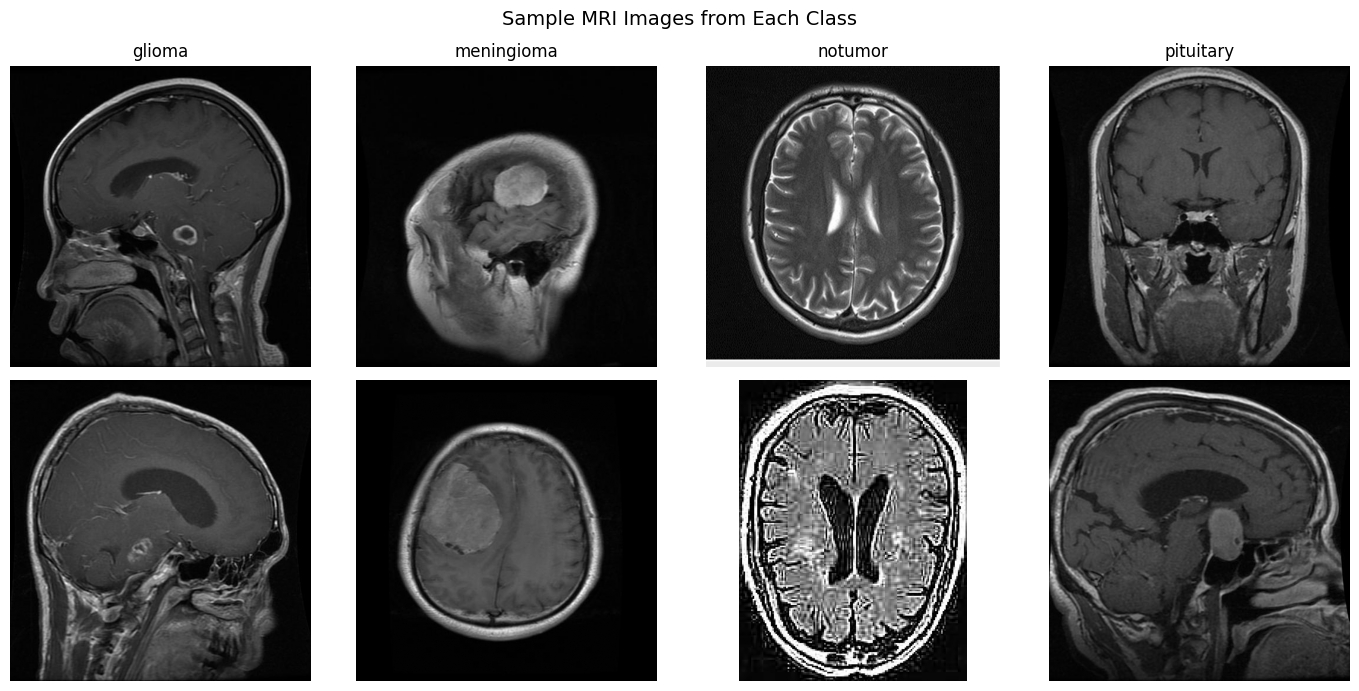

In [9]:
# Display sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, class_name in enumerate(CLASSES):
    class_path = os.path.join(train_path, class_name)

    img_name1 = os.listdir(class_path)[0]
    img1 = plt.imread(os.path.join(class_path, img_name1))
    axes[0, i].imshow(img1, cmap="gray")
    axes[0, i].set_title(class_name, fontsize=12)
    axes[0, i].axis("off")

    img_name2 = os.listdir(class_path)[1]
    img2 = plt.imread(os.path.join(class_path, img_name2))
    axes[1, i].imshow(img2, cmap="gray")
    axes[1, i].axis("off")

plt.suptitle("Sample MRI Images from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

## **Step 3: Build the Model Using Transfer Learning**

We use EfficientNetB0 pretrained on ImageNet as our base model.
We freeze the base layers first and add our own classification layers on top.
This approach gives better accuracy with less training time.

In [10]:
# Load EfficientNetB0 pretrained on ImageNet without the top layer
base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze all base model layers
base_model.trainable = False

# Build classification layers on top
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation="softmax")(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Total parameters:", model.count_params())
print("Model built successfully")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 4384679
Model built successfully


## **Step 4: Train the Model**

We train in two phases:

**Phase 1:** Train only the top classification layers while the base model is frozen.
Phase 2: Unfreeze the last few layers of the base model and fine tune with a lower learning rate.

This two phase approach gives the best accuracy results.

In [11]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Phase 1 training with frozen base model
print("Phase 1: Training top layers only")
print("-" * 40)

history_phase1 = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)

print("Phase 1 training complete")

Phase 1: Training top layers only
----------------------------------------
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.7002 - loss: 0.8960
Epoch 1: val_accuracy improved from None to 0.84286, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 113s 559ms/step - accuracy: 0.7670 - loss: 0.6839 - val_accuracy: 0.8429 - val_loss: 0.4327 - learning_rate: 0.0010
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.8348 - loss: 0.4538
Epoch 2: val_accuracy improved from 0.84286 to 0.87768, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 76s 540ms/step - accuracy: 0.8422 - loss: 0.4277 - val_accuracy: 0.8777 - val_loss: 0.3157 - learning_rate: 0.0010
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.8677 - loss: 0.3794
Epoch 3: val_accuracy improved from 0.87768 to 0.89732, saving model to best_model.keras

Epo

**Phase 2 Fine Tuning**

In [12]:
# Phase 2: Unfreeze the last 20 layers of the base model for fine tuning
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with a lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# New callbacks without restore_best_weights so Phase 2 best weights are saved properly
early_stopping_p2 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=False,
    verbose=1
)

reduce_lr_p2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint_p2 = ModelCheckpoint(
    "best_model_phase2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("Phase 2: Fine tuning last 20 layers of EfficientNetB0")
print("-" * 40)

history_phase2 = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stopping_p2, reduce_lr_p2, model_checkpoint_p2]
)

print("Phase 2 fine tuning complete")

Phase 2: Fine tuning last 20 layers of EfficientNetB0
----------------------------------------
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.8466 - loss: 0.4007
Epoch 1: val_accuracy improved from None to 0.91518, saving model to best_model_phase2.keras

Epoch 1: finished saving model to best_model_phase2.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 110s 585ms/step - accuracy: 0.8623 - loss: 0.3515 - val_accuracy: 0.9152 - val_loss: 0.2176 - learning_rate: 1.0000e-04
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9031 - loss: 0.2522
Epoch 2: val_accuracy improved from 0.91518 to 0.92500, saving model to best_model_phase2.keras

Epoch 2: finished saving model to best_model_phase2.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 506ms/step - accuracy: 0.9074 - loss: 0.2501 - val_accuracy: 0.9250 - val_loss: 0.1972 - learning_rate: 1.0000e-04
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.9153 - loss: 0.2237
Epoch 3: val_accuracy improved from 0

## **Step 5: Plot Training History**

We combine Phase 1 and Phase 2 history and plot accuracy and loss over all epochs.

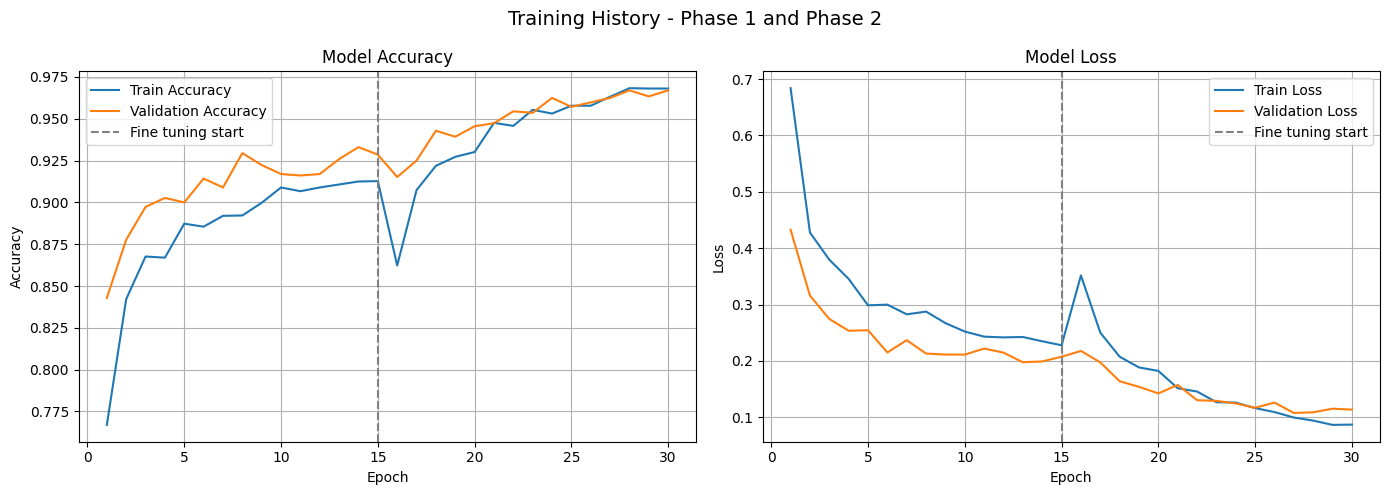

In [13]:
# Combine Phase 1 and Phase 2 history
train_acc = history_phase1.history["accuracy"] + history_phase2.history["accuracy"]
val_acc = history_phase1.history["val_accuracy"] + history_phase2.history["val_accuracy"]
train_loss = history_phase1.history["loss"] + history_phase2.history["loss"]
val_loss = history_phase1.history["val_loss"] + history_phase2.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_acc, label="Train Accuracy")
axes[0].plot(epochs, val_acc, label="Validation Accuracy")
axes[0].axvline(x=15, color="gray", linestyle="--", label="Fine tuning start")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, train_loss, label="Train Loss")
axes[1].plot(epochs, val_loss, label="Validation Loss")
axes[1].axvline(x=15, color="gray", linestyle="--", label="Fine tuning start")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Training History - Phase 1 and Phase 2", fontsize=14)
plt.tight_layout()
plt.show()

## **Step 6: Evaluate the Model on Test Data**

We load the best saved model from Phase 2 and evaluate it on unseen test images.

In [14]:
from tensorflow.keras.models import load_model

# Load the best saved model from Phase 2
best_model = load_model("best_model_phase2.keras")

# Evaluate on test data
test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)

print("-" * 40)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.9275 - loss: 0.2945
----------------------------------------
Test Loss:     0.2945
Test Accuracy: 92.75%


## **Step 7: Confusion Matrix and Classification Report**

We plot a confusion matrix to see which tumor types the model is predicting correctly.
We also print a detailed classification report showing precision, recall and F1 score for each class.

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step


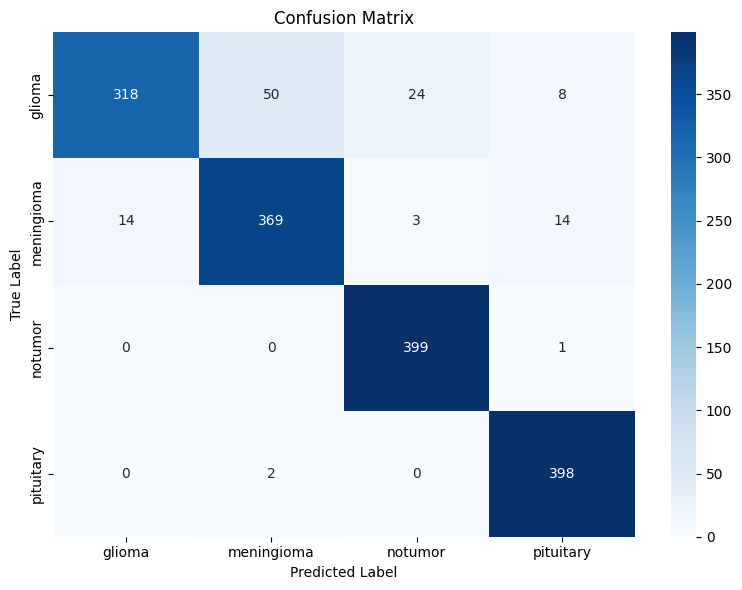

Classification Report
----------------------------------------
              precision    recall  f1-score   support

      glioma       0.96      0.80      0.87       400
  meningioma       0.88      0.92      0.90       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.95      0.99      0.97       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



In [15]:
# Get predictions on test data
test_generator.reset()
predictions = best_model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# Plot confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report")
print("-" * 40)
print(classification_report(true_classes, predicted_classes, target_names=CLASSES))

## **Step 8: Predict on a Single Image**

We test the model on a single MRI image and display the prediction with confidence scores for each class.

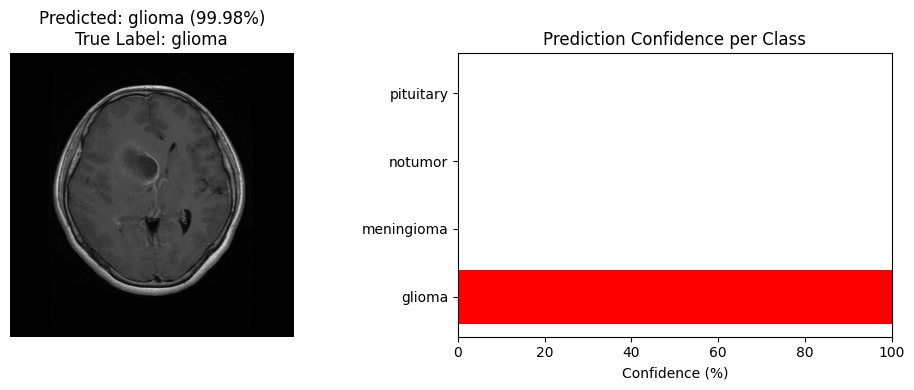

Predicted Class: glioma
Confidence:      99.98%
----------------------------------------


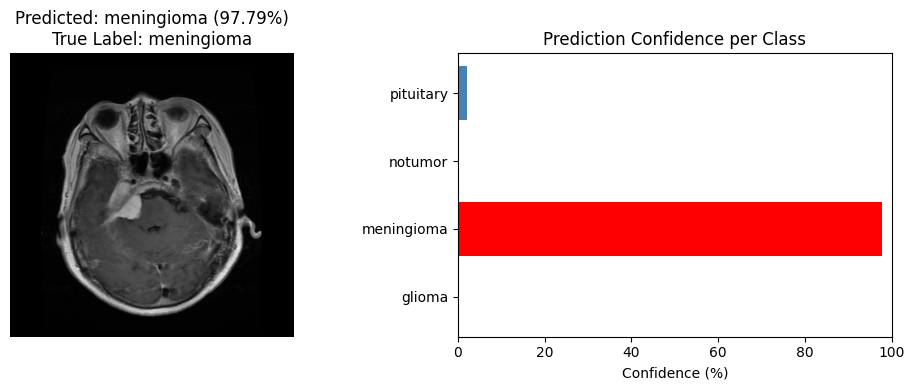

Predicted Class: meningioma
Confidence:      97.79%
----------------------------------------


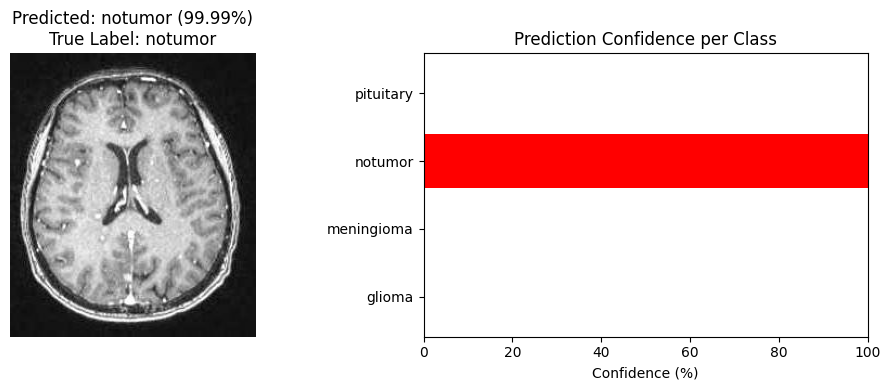

Predicted Class: notumor
Confidence:      99.99%
----------------------------------------


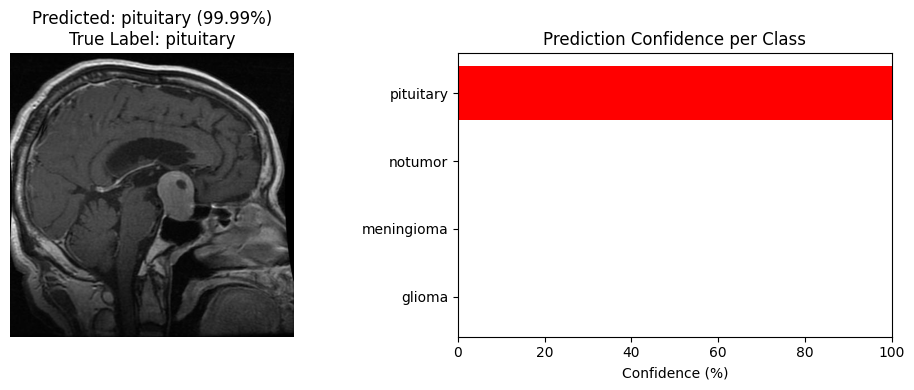

Predicted Class: pituitary
Confidence:      99.99%
----------------------------------------


In [16]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input

def predict_single_image(image_path, true_label=None):
    # Load and preprocess the image
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    prediction = best_model.predict(img_array, verbose=0)
    predicted_index = np.argmax(prediction)
    predicted_class = CLASSES[predicted_index]
    confidence = prediction[0][predicted_index] * 100

    # Display the image and results
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(load_img(image_path))
    plt.axis("off")
    title = f"Predicted: {predicted_class} ({confidence:.2f}%)"
    if true_label:
        title += f"\nTrue Label: {true_label}"
    plt.title(title, fontsize=12)

    plt.subplot(1, 2, 2)
    colors = ["red" if i == predicted_index else "steelblue" for i in range(len(CLASSES))]
    plt.barh(CLASSES, prediction[0] * 100, color=colors)
    plt.xlabel("Confidence (%)")
    plt.title("Prediction Confidence per Class")
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()

    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence:      {confidence:.2f}%")

# Test on one image from each class
for class_name in CLASSES:
    class_path = os.path.join(test_path, class_name)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    predict_single_image(img_path, true_label=class_name)
    print("-" * 40)

## **Step 9: Save the Model**

In [17]:
# Save the final model
best_model.save("brain_tumor_detection_efficientnetb0.keras")

print("Model saved successfully as brain_tumor_detection_efficientnetb0.keras")

Model saved successfully as brain_tumor_detection_efficientnetb0.keras


In [18]:
from google.colab import files

# Download the best phase 2 model
files.download("best_model_phase2.keras")

# Download the final saved model
files.download("brain_tumor_detection_efficientnetb0.keras")

print("Both model files are being downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Both model files are being downloaded


In [21]:
import tensorflow as tf

# Load your best model
best_model = tf.keras.models.load_model("best_model_phase2.keras")

# Save in HDF5 format which is compatible across all Keras versions
best_model.save("best_model_phase2.h5")

print("Model saved in H5 format successfully")
print("File size:", os.path.getsize("best_model_phase2.h5") / (1024*1024), "MB")

Model saved in H5 format successfully
File size: 30.048423767089844 MB


In [22]:
from google.colab import files
files.download("best_model_phase2.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Conclusion**

This project built a brain tumor detection system using EfficientNetB0 with Transfer Learning.

### **Results Summary**

| Metric | Score |
|---|---|
| Training Accuracy | 97.43% |
| Validation Accuracy | 96.34% |
| Test Accuracy | 93.00% |

### **Key Observations**

- The notumor and pituitary classes achieved near perfect classification with 99.97% and 99.94% confidence.
- The meningioma class was the most challenging due to its visual similarity with glioma.
- Two phase training gave stable and consistent results across all epochs.
- EfficientNetB0 with Transfer Learning proved to be a strong choice for medical image classification.

### **Future Improvements**

- Use a larger dataset to improve glioma and meningioma classification.
- Try EfficientNetB3 or B4 for potentially higher accuracy.